# K-Nearest Neighbors (KNN) Classifier

## What is KNN?

K-Nearest Neighbors (KNN) is a **supervised classification algorithm** that predicts the class of a new data point based on the **majority class of its K nearest training data points**.

Examples:

* Spam / Not Spam
* Loan Approved / Rejected
* Disease Positive / Negative
* Customer Will Buy / Will Not Buy

KNN is called a **lazy learning algorithm** because it **does not build a mathematical model during training**. It simply stores the training data.

---

# How KNN Works

Suppose:

| Age | Income | Buy |
| --- | ------ | --- |
| 22  | 25k    | No  |
| 25  | 30k    | No  |
| 35  | 60k    | Yes |
| 40  | 65k    | Yes |
| 42  | 70k    | Yes |

New customer:

```text
Age = 38
Income = 62k
```

Choose:

```text
K = 3
```

Nearest neighbors:

```text
35,60k → Yes
40,65k → Yes
42,70k → Yes
```

Majority vote:

```text
Yes
```

Prediction:

```text
Buy = Yes
```

---

# What Does K Mean?

K is the **number of nearest neighbors** considered.

Examples:

```text
K = 1
```

Use only the closest point.

```text
K = 3
```

Use the 3 closest points.

```text
K = 5
```

Use the 5 closest points.

Choosing K is a **hyperparameter tuning problem**.

---

# Distance in KNN

The most common distance metric is **Euclidean Distance**.

Distance between two points:

```text
d = √[(x₂ − x₁)² + (y₂ − y₁)²]
```

Example:

```text
A = (2,3)
B = (5,7)

Distance
= √[(5−2)² + (7−3)²]
= √(9 + 16)
= √25
= 5
```

KNN computes the distance from the new point to **every training point**.

---

# Why Scaling is Important

Suppose:

| Feature | Range            |
| ------- | ---------------- |
| Age     | 18–60            |
| Salary  | 20,000–1,000,000 |

Without scaling:

```text
Age difference    = 5
Salary difference = 50,000
```

Salary dominates the distance calculation.

Therefore KNN usually requires:

```python
StandardScaler()
```

After scaling:

```text
Age      Salary

-0.8     -1.1
-0.3     -0.4
```

Both features contribute fairly.

---

# Why OneHotEncoder is Needed

Suppose:

| Age | Gender | Buy |
| --- | ------ | --- |
| 25  | Male   | Yes |
| 30  | Female | No  |

KNN cannot use text values directly.

Use:

```python
OneHotEncoder()
```

Result:

| Male | Female |
| ---- | ------ |
| 1    | 0      |
| 0    | 1      |

---

# Why ColumnTransformer?

Real datasets contain both **numerical and categorical features**.

Example:

| Column | Type        |
| ------ | ----------- |
| Age    | Numerical   |
| Salary | Numerical   |
| Gender | Categorical |
| City   | Categorical |

We want:

```text
Numerical
    ↓
StandardScaler

Categorical
    ↓
OneHotEncoder
```

This is handled by:

```python
ColumnTransformer()
```

---

# Pipeline + KNN

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

numeric_features = ["Age", "Salary"]
categorical_features = ["Gender", "City"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
```

Flow:

```text
Raw Data
    ↓
ColumnTransformer
    ├── StandardScaler
    └── OneHotEncoder
    ↓
KNN Classifier
```

---

# Training and Prediction

```python
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

The Pipeline automatically performs:

* Encoding
* Scaling
* Classification

---

# Important Hyperparameters

| Parameter   | Meaning                                      |
| ----------- | -------------------------------------------- |
| n_neighbors | Number of neighbors (K)                      |
| weights     | Uniform or distance-based voting             |
| metric      | Distance metric (Euclidean, Manhattan, etc.) |

Example:

```python
KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform"
)
```

---

# Choosing the Best K

Small K:

```text
K = 1
```

* Very flexible
* Can overfit
* Sensitive to noise

Large K:

```text
K = 50
```

* Very smooth
* Can underfit
* Ignores local patterns

Typical approach:

```python
params = {
    "knn__n_neighbors": [3,5,7,9,11]
}
```

Use:

```python
GridSearchCV()
```

to find the best K.

---

# Evaluation Metrics

For classification:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix
* ROC-AUC

---

# Advantages of KNN

* Very easy to understand
* No training phase
* Can model non-linear decision boundaries
* Works well for small and medium datasets

---

# Disadvantages of KNN

* Prediction becomes slow for large datasets
* Requires feature scaling
* Sensitive to irrelevant features
* Sensitive to the choice of K

---

# Interview Answer

**What is KNN?**

K-Nearest Neighbors (KNN) is a supervised classification algorithm that predicts the class of a new data point based on the majority class of its K nearest training data points using a distance metric such as Euclidean distance.

---

# Quick Recall Diagram

```text
Training Data
      ● ● ●
   ●  ●  ●  ○
      ○ ○ ○
         ?

Choose K
    ↓
Compute Distances
    ↓
Select K Nearest Points
    ↓
Majority Vote
    ↓
Predicted Class
```

---

# KNN Workflow

```text
Raw Data
    ↓
Train/Test Split
    ↓
ColumnTransformer
    ├── StandardScaler
    └── OneHotEncoder
    ↓
KNN Classifier
    ↓
Cross Validation
    ↓
GridSearchCV (Best K)
    ↓
Final Prediction
```

---

# Golden Rule

**KNN predicts by comparing a new point with the nearest training points, so feature scaling is usually essential and categorical features should be encoded before distance calculations.**


In [2]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 

In [3]:
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [4]:
X.shape

(4601, 57)

In [5]:
y.sample(10
    )

,Class
4551,0
391,1
4356,0
311,1
503,1
3123,0
3295,0
4373,0
3445,0
281,1


In [6]:
X.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [7]:
X.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,10.000000,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [9]:
X.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4596    False
4597    False
4598    False
4599    False
4600    False
Length: 4601, dtype: bool

In [10]:
y[y.duplicated()].value_counts()

Class
0        2787
1        1812
Name: count, dtype: int64

In [11]:
import pandas as pd 
mails = pd.concat([X,y],axis=1)
mails

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [12]:
mails.duplicated().sum()

391

In [13]:
mails = mails.drop_duplicates()
mails

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [14]:
mails.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [15]:
mails.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [16]:
print(mails.columns.tolist())

['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capita

In [20]:
mails = X.copy()
mails["Class"] = y

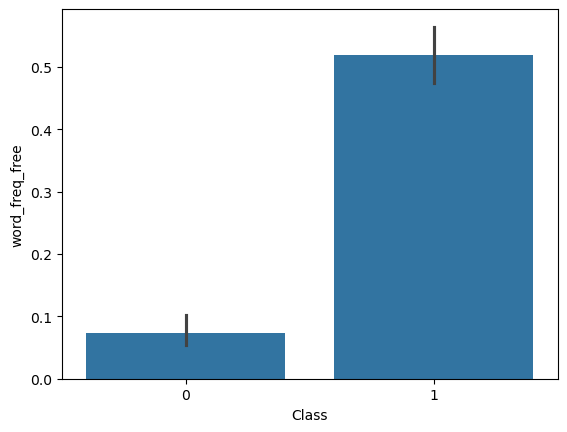

In [21]:
sns.barplot(data=mails, x="Class", y="word_freq_free")
plt.show()

In [22]:
y.head()

,Class
0,1
1,1
2,1
3,1
4,1


In [23]:
mails = X.copy()
mails["Class"] = y.iloc[:, 0]

In [24]:
mails.columns.tolist()

['word_freq_make',
 'word_freq_address',
 'word_freq_all',
 'word_freq_3d',
 'word_freq_our',
 'word_freq_over',
 'word_freq_remove',
 'word_freq_internet',
 'word_freq_order',
 'word_freq_mail',
 'word_freq_receive',
 'word_freq_will',
 'word_freq_people',
 'word_freq_report',
 'word_freq_addresses',
 'word_freq_free',
 'word_freq_business',
 'word_freq_email',
 'word_freq_you',
 'word_freq_credit',
 'word_freq_your',
 'word_freq_font',
 'word_freq_000',
 'word_freq_money',
 'word_freq_hp',
 'word_freq_hpl',
 'word_freq_george',
 'word_freq_650',
 'word_freq_lab',
 'word_freq_labs',
 'word_freq_telnet',
 'word_freq_857',
 'word_freq_data',
 'word_freq_415',
 'word_freq_85',
 'word_freq_technology',
 'word_freq_1999',
 'word_freq_parts',
 'word_freq_pm',
 'word_freq_direct',
 'word_freq_cs',
 'word_freq_meeting',
 'word_freq_original',
 'word_freq_project',
 'word_freq_re',
 'word_freq_edu',
 'word_freq_table',
 'word_freq_conference',
 'char_freq_;',
 'char_freq_(',
 'char_freq_[',
 '

In [25]:
print(mails.columns.tolist())

['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capita

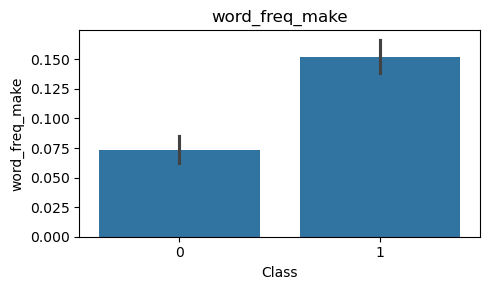

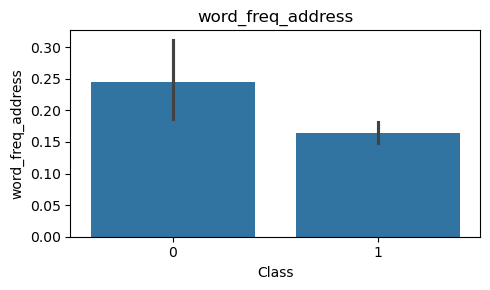

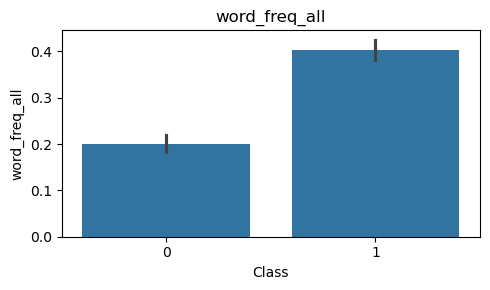

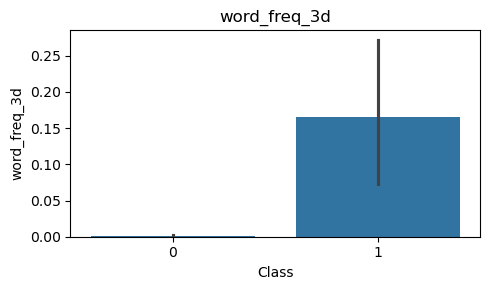

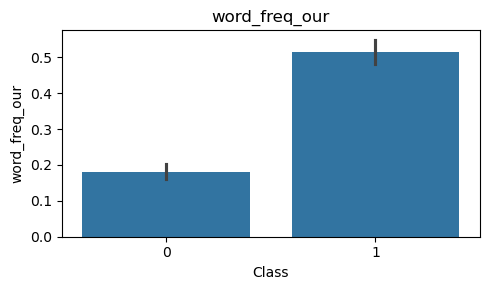

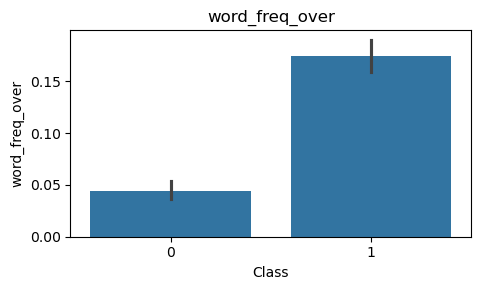

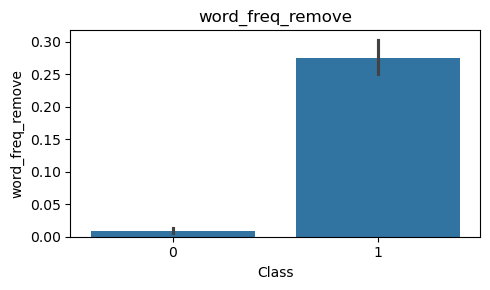

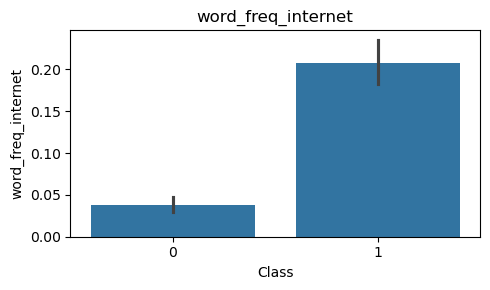

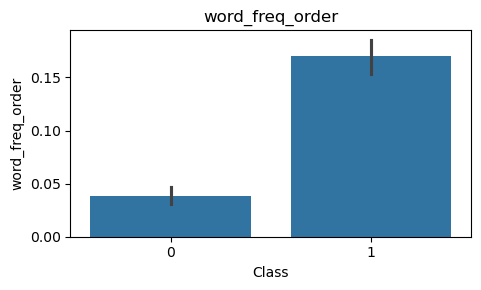

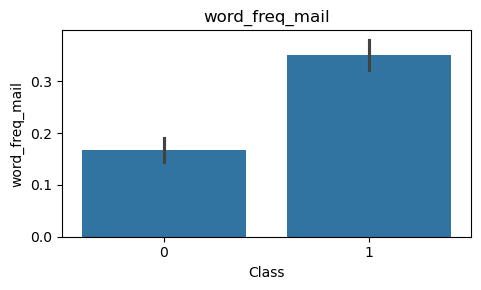

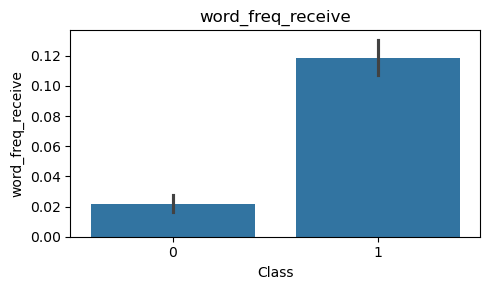

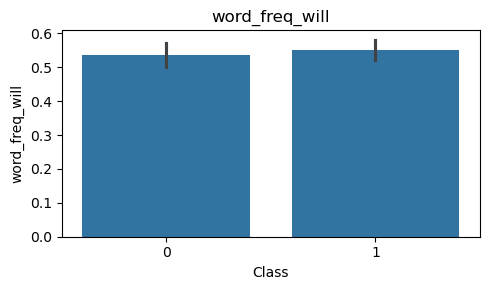

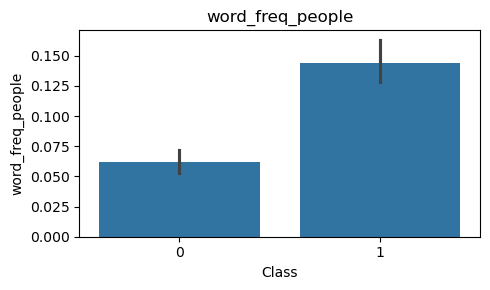

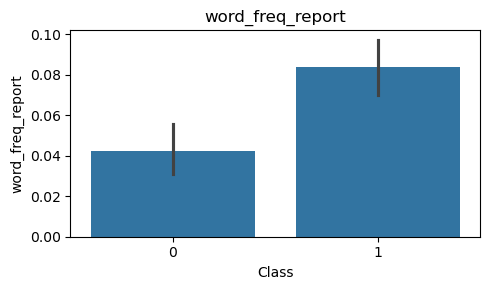

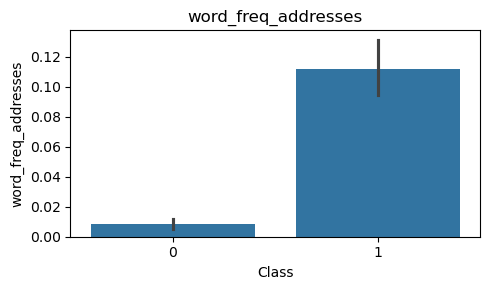

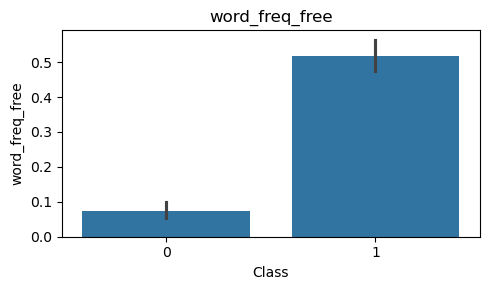

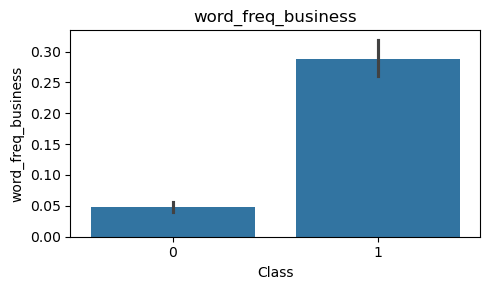

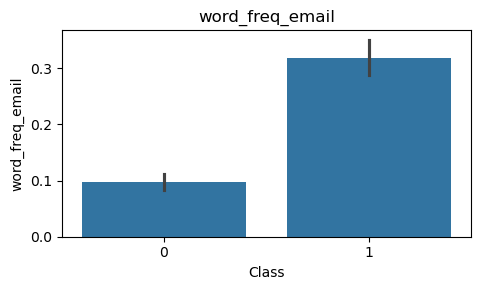

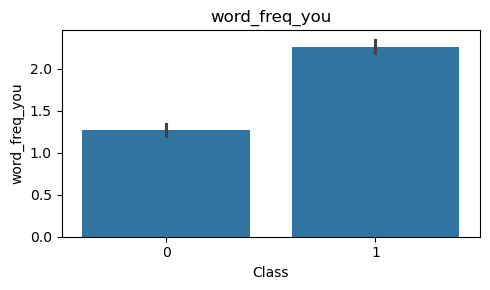

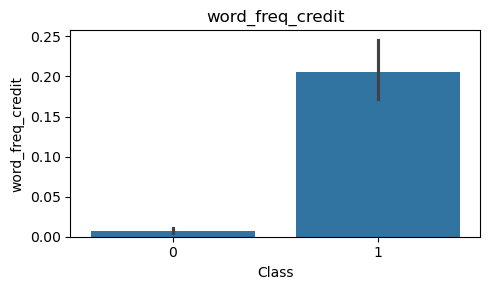

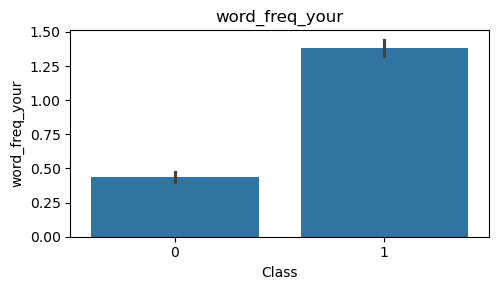

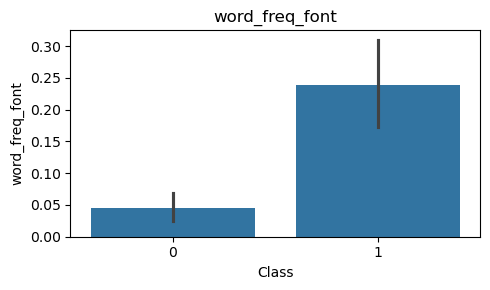

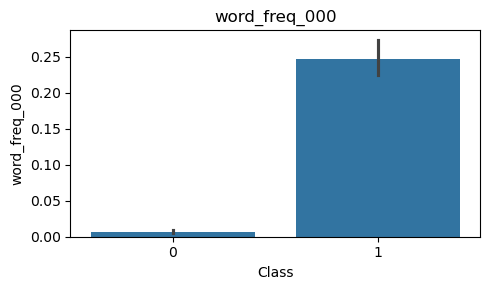

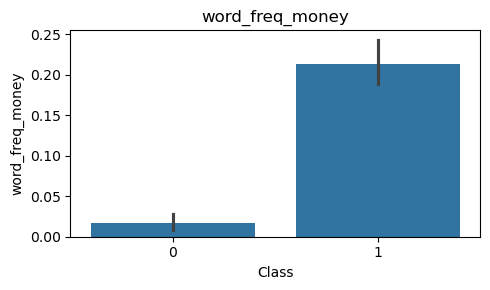

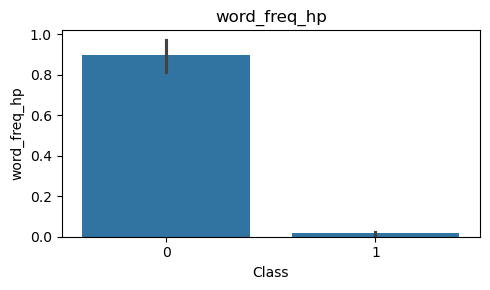

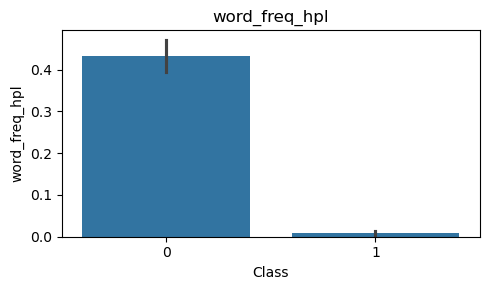

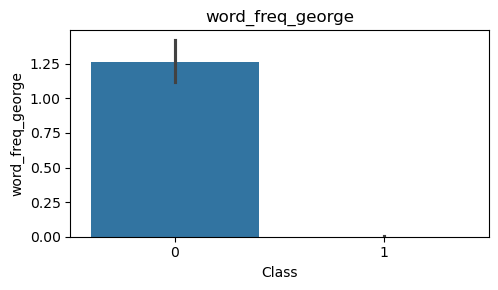

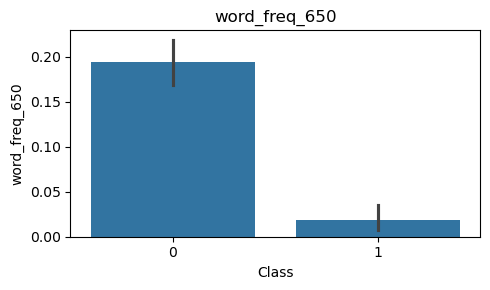

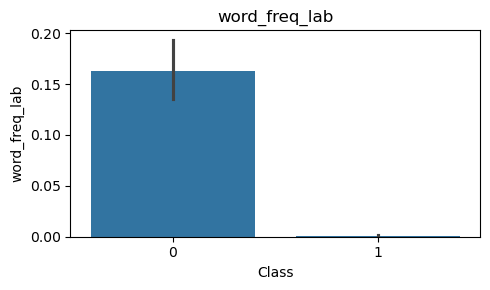

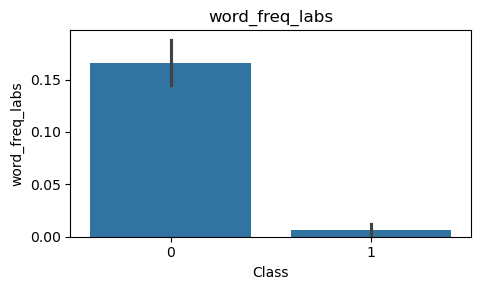

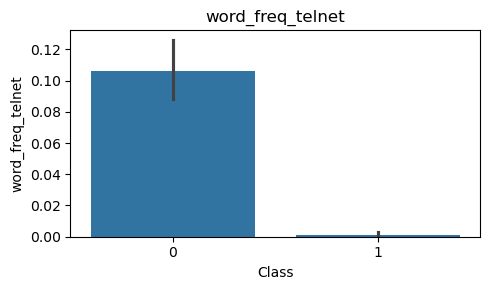

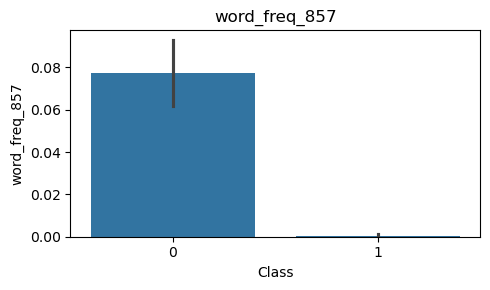

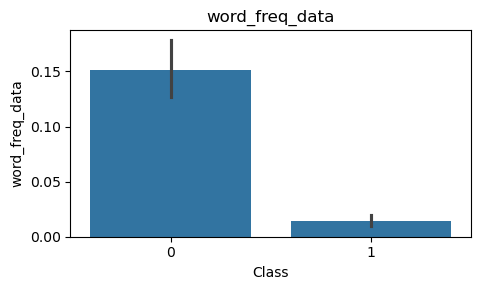

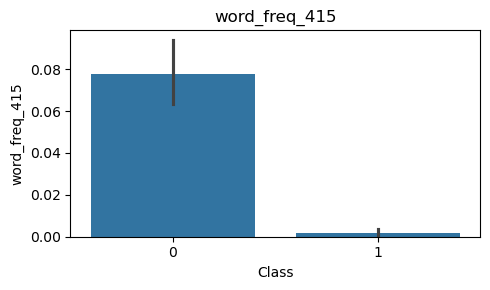

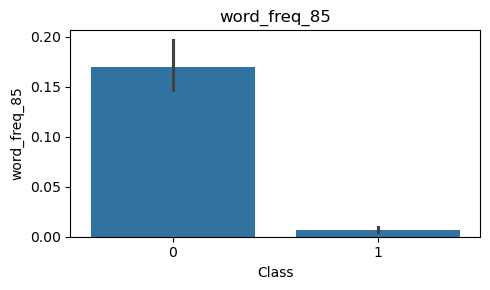

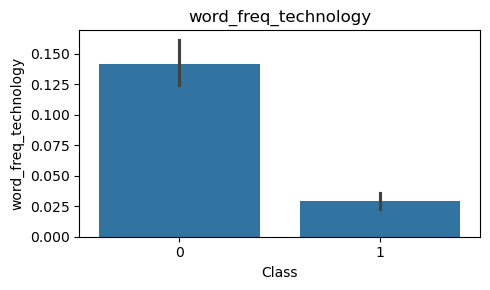

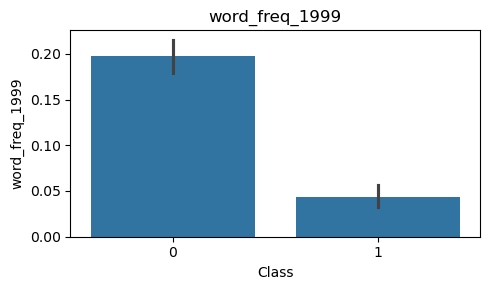

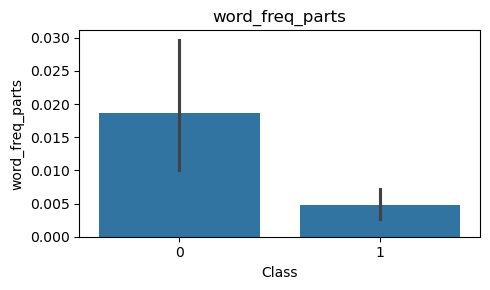

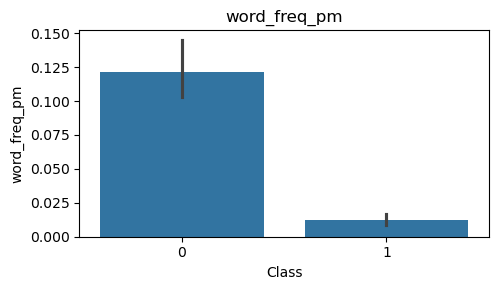

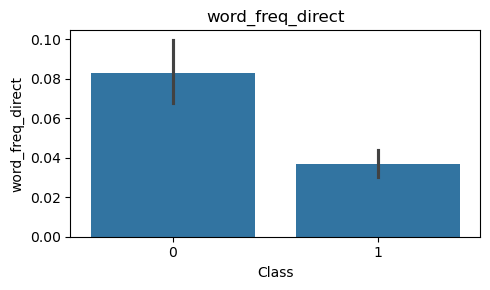

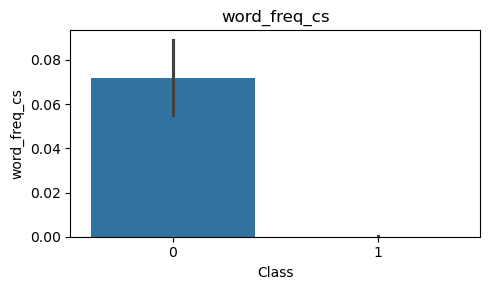

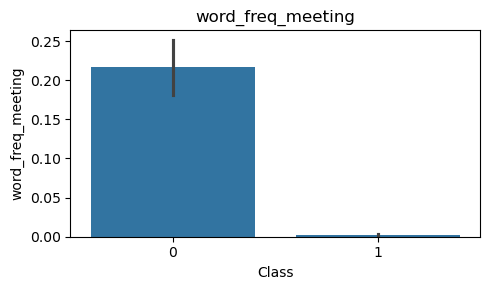

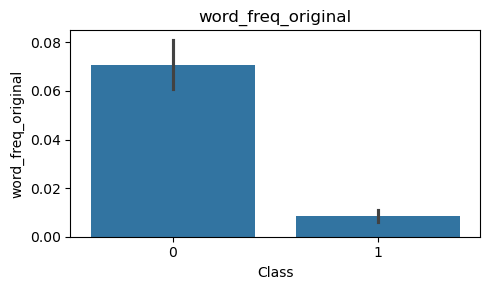

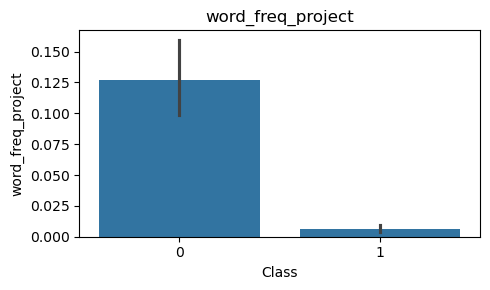

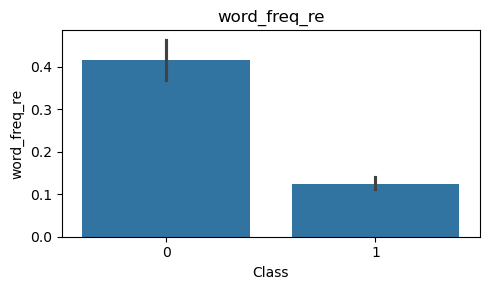

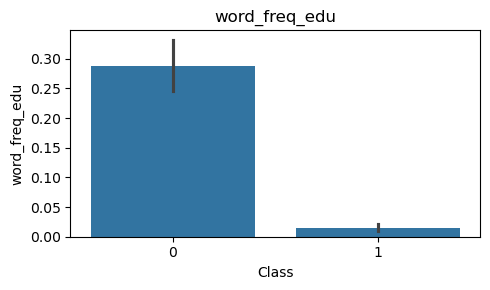

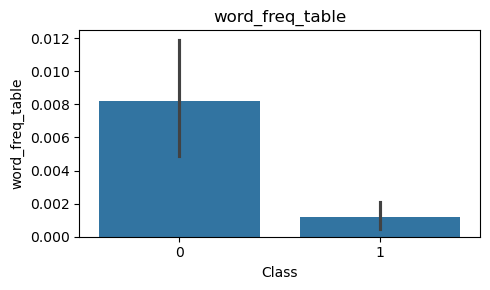

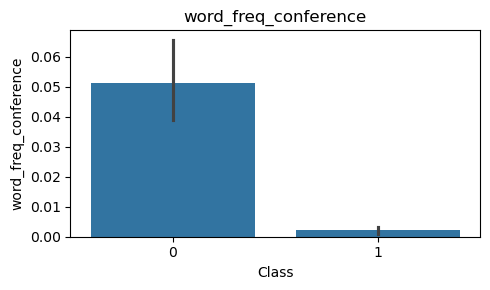

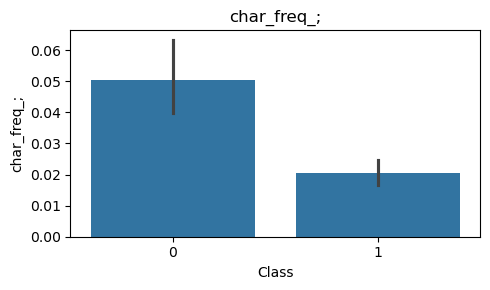

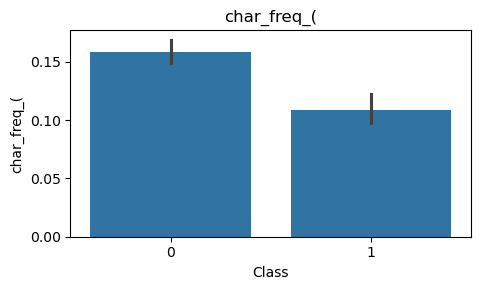

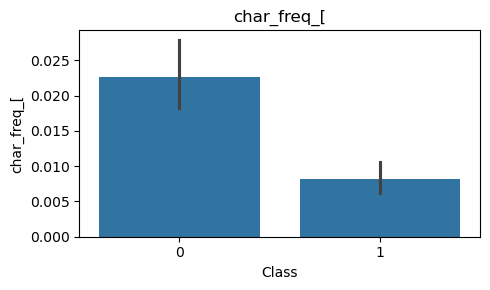

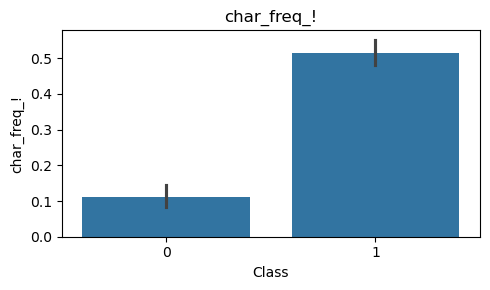

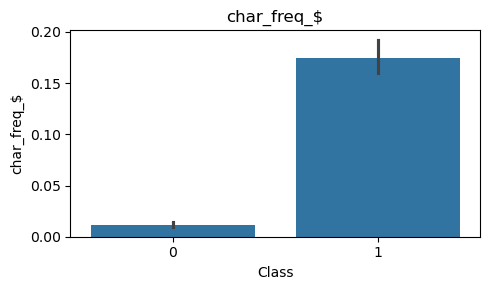

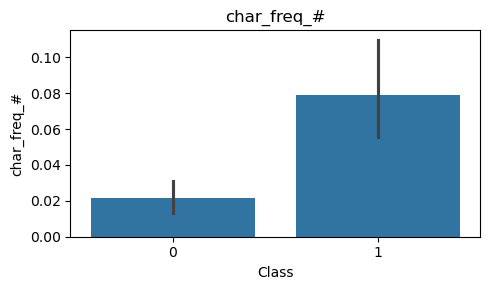

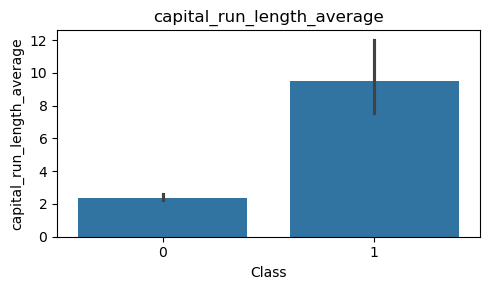

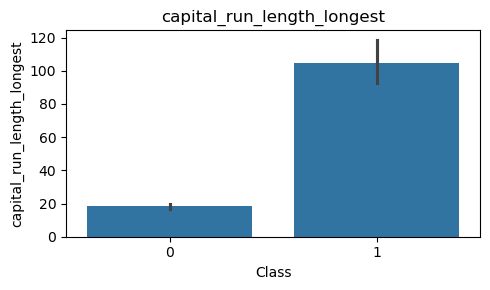

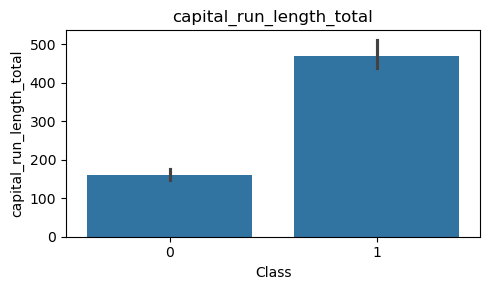

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [col for col in mails.columns if col != "Class"]

for feature in features:
    plt.figure(figsize=(5,3))
    sns.barplot(data=mails, x="Class", y=feature)
    plt.title(feature)
    plt.tight_layout()
    plt.show()

In [27]:
feature_diff = (
    mails.groupby("Class").mean().diff().iloc[-1].abs().sort_values(ascending=False)
)

top_features = feature_diff.head(10)
print(top_features)

capital_run_length_total      309.148468
capital_run_length_longest     86.178780
capital_run_length_average      7.141864
word_freq_george                1.263716
word_freq_you                   0.994199
word_freq_your                  0.941668
word_freq_hp                    0.877994
word_freq_free                  0.444775
word_freq_hpl                   0.422822
char_freq_!                     0.403729
Name: 1, dtype: float64


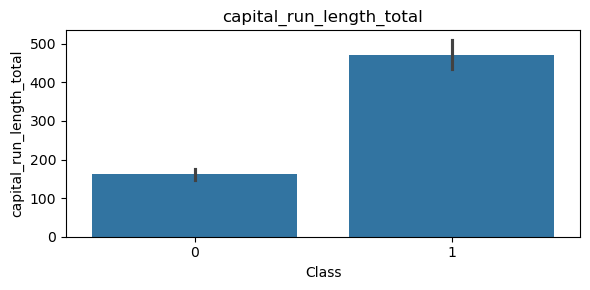

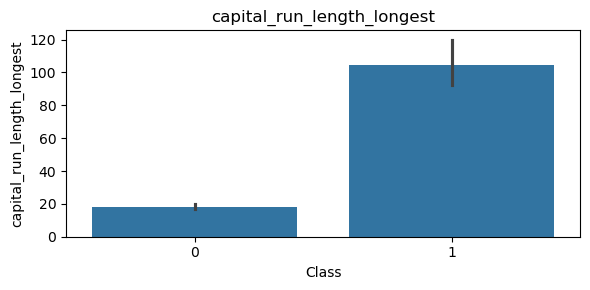

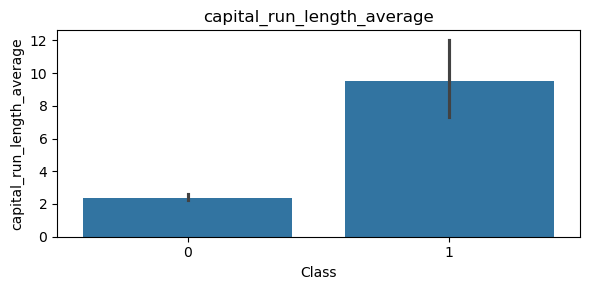

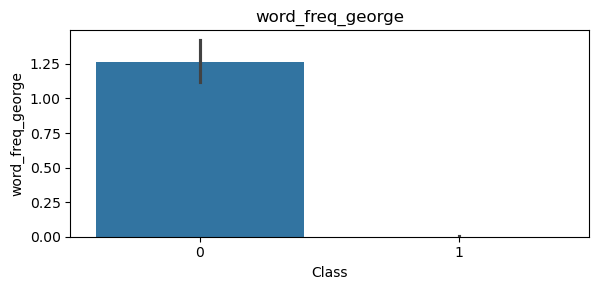

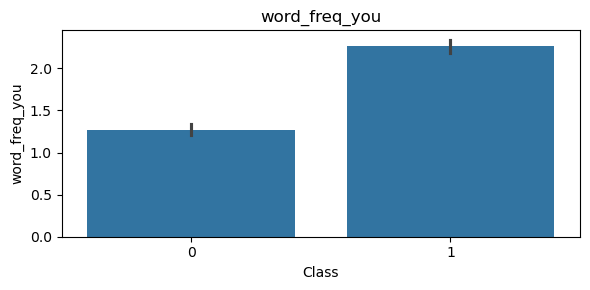

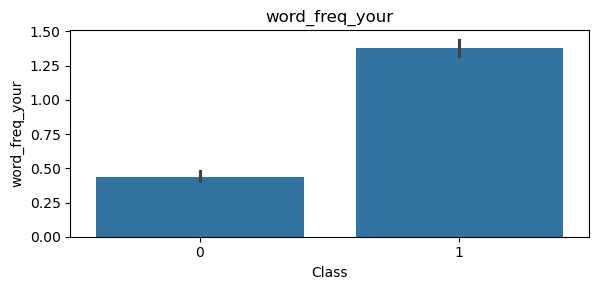

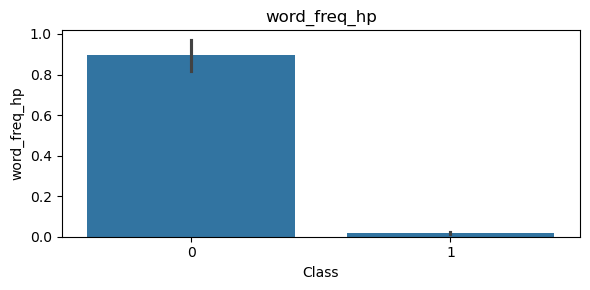

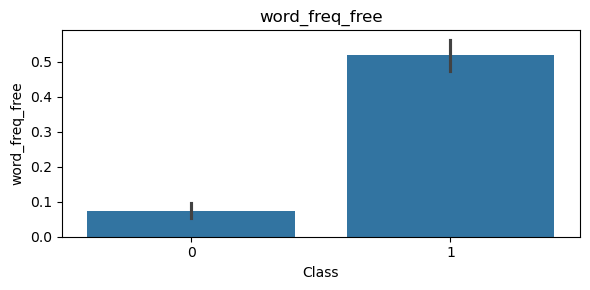

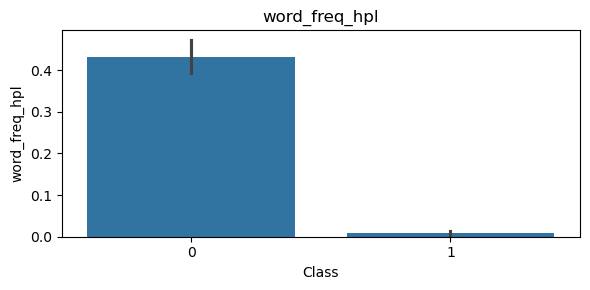

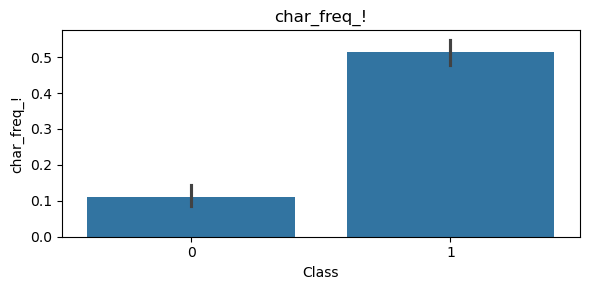

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot only the selected top features
for feature in top_features.index:
    plt.figure(figsize=(6,3))
    sns.barplot(data=mails, x="Class", y=feature)
    plt.title(feature)
    plt.tight_layout()
    plt.show()

In [29]:
selected_features = [
    "capital_run_length_total",
    "capital_run_length_longest",
    "capital_run_length_average",
    "word_freq_george",
    "word_freq_you",
    "word_freq_your",
    "word_freq_hp",
    "word_freq_free",
    "word_freq_hpl",
    "char_freq_!"
]

x = mails[selected_features]
y = mails["Class"]

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
knn_model = Pipeline([
    ("scalar",StandardScaler()),
    ("knn",KNeighborsClassifier())
])
knn_model.fit(X_train,y_train)

Pipeline(steps=[('scalar', StandardScaler()), ('knn', KNeighborsClassifier())])

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9077090119435396
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       558
           1       0.89      0.88      0.88       363

    accuracy                           0.91       921
   macro avg       0.90      0.90      0.90       921
weighted avg       0.91      0.91      0.91       921



In [39]:
from sklearn.model_selection import GridSearchCV

params = {
    "knn__n_neighbors": [3,5,7,9,11,15,21]
}

grid = GridSearchCV( knn_model, params, cv=5, scoring="accuracy" )

grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best K: {'knn__n_neighbors': 3}
Best CV Accuracy: 0.9105978260869566


In [40]:
from sklearn.metrics import accuracy_score

best_knn = grid.best_estimator_

# Predictions
train_pred = best_knn.predict(X_train)
test_pred = best_knn.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Train Accuracy: 0.9524456521739131
Test Accuracy : 0.8979370249728555


In [41]:
best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8979370249728555
[[512  46]
 [ 48 315]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       558
           1       0.87      0.87      0.87       363

    accuracy                           0.90       921
   macro avg       0.89      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



# Why Did GridSearchCV Change from K=7 to K=3?

The training data changed.

First split:

```python
train_test_split(X, y, test_size=0.2, random_state=42)
```

Second split:

```python
train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

Adding `stratify=y` creates a **different training set** while preserving class proportions.

KNN is sensitive to the exact training points, so the best value of `K` can change.

GridSearchCV selects the `K` with the **highest average cross-validation accuracy**.

A change from **K=7 to K=3** is normal when the training split changes.

The important comparison is the **CV accuracy**, not just the value of `K`.


# Classification Evaluation Metrics Cheat Sheet

## Step 1: Start with the Confusion Matrix

```text id=
```


## Step 1: Start with the Confusion Matrix

A confusion matrix is the **foundation of all classification metrics**.

```text
                    Predicted
                Negative   Positive

Actual Negative     TN         FP
Actual Positive     FN         TP
```

### Meaning of each term

* **TN (True Negative):** Actual negative predicted as negative.
* **FP (False Positive):** Actual negative predicted as positive.
* **FN (False Negative):** Actual positive predicted as negative.
* **TP (True Positive):** Actual positive predicted as positive.

Example (Spam Classification):

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

Interpretation:

* **493** → Correctly identified non-spam emails (**TN**)
* **65** → Normal emails wrongly marked as spam (**FP**)
* **59** → Spam emails missed by the model (**FN**)
* **304** → Correctly detected spam emails (**TP**)

All major classification metrics (Accuracy, Precision, Recall, F1-score, and Specificity) are calculated from these four values.


## Step 2: Accuracy

### Formula

```text id=
```


## Step 2: Accuracy

### Formula

```text
Accuracy = (TP + TN) / (TP + TN + FP + FN)
```

### What does Accuracy mean?

Accuracy tells us **how many predictions the model got correct out of all predictions**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

Here:

* **TP = 304**
* **TN = 493**
* **FP = 65**
* **FN = 59**

Calculation:

```text
Accuracy = (304 + 493) / (304 + 493 + 65 + 59)

         = 797 / 921

         = 0.865
```

**Accuracy = 86.5%**

### Interpretation

Out of **921 emails**, the model correctly classified **797 emails**.

### When should I use Accuracy?

Use Accuracy when the classes are **balanced** (roughly similar numbers of Class 0 and Class 1).

Examples:

* Cat vs Dog
* Apple vs Orange
* Digit classification

### When should I avoid Accuracy?

Avoid Accuracy when the dataset is **imbalanced**.

Example:

```text
990 normal emails
10 spam emails
```

If the model predicts **all emails as normal**:

```text
Accuracy = 990 / 1000 = 99%
```

The model looks excellent, but it detected **zero spam emails**.

### Memory Trick

```text
Accuracy = Overall Correctness
```

Ask yourself:

> “Out of everything, how many predictions were correct?”


## Step 3: Precision

### Formula

```text id=
```


## Step 3: Precision

### Formula

```text
Precision = TP / (TP + FP)
```

### What does Precision mean?

Precision answers:

> **When the model predicts Positive, how often is it correct?**

It measures the **quality of positive predictions**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

For the **Spam class (Positive = Spam)**:

* **TP = 304**
* **FP = 65**

Calculation:

```text
Precision = 304 / (304 + 65)

          = 304 / 369

          = 0.824
```

**Precision = 82.4%**

### Interpretation

The model predicted **369 emails as Spam**.

Out of those, **304 were actually Spam**.

So when the model says **“Spam”**, it is correct **82.4% of the time**.

### When should I use Precision?

Use Precision when **False Positives are expensive**.

Examples:

* Spam detection (important emails should not go to spam)
* Loan approval
* Criminal identification
* Medical diagnosis where unnecessary treatment is harmful

### Real-World Example

Suppose a spam filter predicts:

```text
Predicted Spam = 100 emails
Actually Spam  = 90 emails
```

Then:

```text
Precision = 90 / 100 = 90%
```

This means **10 normal emails were incorrectly marked as spam**.

### High vs Low Precision

**High Precision**

```text
Predicted Spam → Mostly true spam
```

Few false alarms.

**Low Precision**

```text
Predicted Spam → Many normal emails included
```

Lots of false alarms.

### Memory Trick

```text
Precision = “When I say YES, am I right?”
```

Ask yourself:

> **“Among all emails predicted as Spam, how many were actually Spam?”**


## Step 4: Recall (Sensitivity)

### Formula

```text id=
```


## Step 4: Recall (Sensitivity)

### Formula

```text
Recall = TP / (TP + FN)
```

### What does Recall mean?

Recall answers:

> **Of all actual positive cases, how many did the model correctly identify?**

It measures the model’s ability to **find positive cases**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

For the **Spam class (Positive = Spam)**:

* **TP = 304**
* **FN = 59**

Calculation:

```text
Recall = 304 / (304 + 59)

       = 304 / 363

       = 0.838
```

**Recall = 83.8%**

### Interpretation

There were **363 actual spam emails**.

The model correctly detected **304 of them**.

So the model found **83.8% of all spam emails**.

### When should I use Recall?

Use Recall when **False Negatives are expensive**.

Examples:

* Cancer detection
* Fraud detection
* Disease screening
* Intrusion detection
* Spam filtering (when missing spam is dangerous)

### Real-World Example

Suppose:

```text
Actual Fraud Cases = 100
Detected Fraud = 95
```

Then:

```text
Recall = 95 / 100 = 95%
```

This means the model successfully found **95% of all fraud cases**.

### High vs Low Recall

**High Recall**

```text
Most actual positive cases are detected.
```

Few missed positives.

**Low Recall**

```text
Many actual positive cases are missed.
```

Many false negatives.

### Precision vs Recall

```text
Precision → Correctness of positive predictions.

Recall    → Completeness of positive detection.
```

### Memory Trick

```text
Recall = “Did I find all YES cases?”
```

Ask yourself:

> **“Among all actual Spam emails, how many did the model detect?”**


## Step 5: F1 Score

### Formula

```text id=
```



## Step 5: F1 Score

### Formula

```text
F1 Score = 2 × (Precision × Recall) / (Precision + Recall)
```

### What does F1 Score mean?

F1 Score is the **harmonic mean of Precision and Recall**.

It gives a **single score that balances both metrics**.

### Example

From our previous calculations:

```text
Precision = 0.824
Recall    = 0.838
```

Calculation:

```text
F1 = 2 × (0.824 × 0.838) / (0.824 + 0.838)

   = 2 × 0.690 / 1.662

   = 0.830
```

**F1 Score = 83.0%**

### Interpretation

The model has a good balance between:

* Correctly predicting Spam (Precision)
* Detecting all Spam emails (Recall)

### When should I use F1 Score?

Use F1 Score when:

* The dataset is **imbalanced**
* Both **Precision and Recall are important**
* You need a **single metric** to compare models

Examples:

* Spam detection
* Fraud detection
* Medical diagnosis
* Information retrieval

### Why not just use Accuracy?

Example:

```text
990 normal emails
10 spam emails
```

Model predicts everything as normal.

```text
Accuracy = 99%
Precision = 0
Recall = 0
F1 = 0
```

Accuracy looks excellent, but the model completely fails to detect spam.

F1 exposes this problem.

### High vs Low F1 Score

**High F1**

```text
Precision high
Recall high
```

Balanced and reliable model.

**Low F1**

```text
Precision low
or
Recall low
```

The model is weak in detecting positive cases or produces many false alarms.

### Memory Trick

```text
F1 Score = Balance of Precision and Recall
```

Ask yourself:

> **“Does my model both predict positive cases correctly and detect most of the actual positive cases?”**


## Step 6: Specificity (True Negative Rate)

### Formula

```text id=
```


## Step 6: Specificity (True Negative Rate)

### Formula

```text
Specificity = TN / (TN + FP)
```

### What does Specificity mean?

Specificity answers:

> **Of all actual negative cases, how many did the model correctly identify?**

It measures the model’s ability to **identify negative cases correctly**.

### Example

Confusion Matrix:

```text
                    Predicted
                Not Spam   Spam

Actual Not Spam     493      65
Actual Spam          59     304
```

For the **Not Spam class (Negative = Not Spam)**:

* **TN = 493**
* **FP = 65**

Calculation:

```text
Specificity = 493 / (493 + 65)

            = 493 / 558

            = 0.883
```

**Specificity = 88.3%**

### Interpretation

There were **558 actual non-spam emails**.

The model correctly identified **493 of them**.

So the model correctly recognized **88.3% of all non-spam emails**.

### When should I use Specificity?

Use Specificity when **correctly identifying negative cases is important**.

Examples:

* Healthy patient identification
* Legitimate transaction detection
* Non-spam email recognition
* Quality control (identifying non-defective products)

### High vs Low Specificity

**High Specificity**

```text
Most actual negative cases are identified correctly.
```

Few false positives.

**Low Specificity**

```text
Many negative cases are wrongly predicted as positive.
```

Many false positives.

### Recall vs Specificity

```text
Recall      → Detects Positive cases correctly.

Specificity → Detects Negative cases correctly.
```

### Memory Trick

```text
Specificity = “Did I correctly reject the NO cases?”
```

Ask yourself:

> **“Among all actual Not Spam emails, how many did the model correctly identify as Not Spam?”**


## Step 7: ROC Curve (Receiver Operating Characteristic Curve)

### What is the ROC Curve?

The **ROC Curve** shows the performance of a classification model at **different probability thresholds**.

It compares:

```text
True Positive Rate (Recall)
            vs
False Positive Rate (FPR)
```

### Formula

```text
True Positive Rate (TPR) = TP / (TP + FN)

False Positive Rate (FPR) = FP / (FP + TN)
```

### What does the ROC Curve show?

As the **classification threshold** changes, the values of **TPR** and **FPR** change.

Example:

```text
Threshold = 0.3 → More emails predicted as Spam
Threshold = 0.7 → Fewer emails predicted as Spam
```

The ROC curve helps us understand the trade-off between:

* Detecting more positive cases (higher Recall)
* Producing more false positives

### Visual Intuition

```text
TPR (Recall)
1.0 |                             *
    |                         *
0.8 |                     *
    |                 *
0.6 |             *
    |         *
0.4 |     *
    |  *
0.2 |*
    +------------------------------------
      0.0   0.2   0.4   0.6   0.8   1.0
               FPR
```

A curve closer to the **top-left corner** indicates a better classifier.

### When should I use ROC Curve?

Use ROC Curve when:

* Comparing multiple classification models
* Evaluating different probability thresholds
* Working with binary classification problems

Examples:

* Spam detection
* Fraud detection
* Medical diagnosis
* Credit risk prediction

### Interpretation

**Better Model**

```text
High TPR
Low FPR
```

**Worse Model**

```text
Low TPR
High FPR
```

### Memory Trick

```text
ROC Curve = “How does the model perform as the decision threshold changes?”
```

Ask yourself:

> **“Can I increase Recall without increasing too many False Positives?”**
